In [1]:
import warnings
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import (
    kruskal,
    mannwhitneyu
)

warnings.filterwarnings("ignore")

pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.float_format",
    lambda x: f"{x:,.3f}"
)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
INPUT_FILE = Path(
    r"C:\Users\bhara\OneDrive\Desktop\Capstone_Project-DAMO-6994-\Capstone_Project-DAMO-6994-\Capstone_Project-DAMO-6994-\data\Explorer Dataset\CTAS_Triage.csv"
)

if not INPUT_FILE.exists():

    raise FileNotFoundError(
        f"\nCTAS dataset was not found:\n{INPUT_FILE}\n\n"
        "Please check the file path."
    )

ctas_df = pd.read_csv(
    INPUT_FILE
)

print("CTAS dataset loaded successfully.")

CTAS dataset loaded successfully.


In [5]:
print(
    f"Rows    : {len(ctas_df):,}"
)

print(
    f"Columns : {ctas_df.shape[1]}"
)

display(
    ctas_df.head()
)

Rows    : 912
Columns : 10


,fiscal_year,fiscal_year_start,sex,triage_level,ctas_urgency_score,age_group,population_category,ed_visits,median_los_minutes,median_los_hours
0,2021-2022,2021,Female,CTAS I - Resuscitation,1,00–19,Pediatric & Youth,10332,240,4.000
1,2021-2022,2021,Female,CTAS I - Resuscitation,1,20–44,Young Adult,11051,330,5.500
2,2021-2022,2021,Female,CTAS I - Resuscitation,1,45–64,Middle Adult,11653,324,5.400
3,2021-2022,2021,Female,CTAS I - Resuscitation,1,65+,Older Adult,25787,414,6.900
4,2021-2022,2021,Male,CTAS I - Resuscitation,1,00–19,Pediatric & Youth,12409,228,3.800


In [6]:
print("=" * 80)
print("CTAS DATASET INFORMATION")
print("=" * 80)

print("\nColumns:")
print(
    ctas_df.columns.tolist()
)

print("\nData types:")
display(
    ctas_df.dtypes
)

print("\nMissing values:")
display(
    ctas_df.isna().sum()
)

CTAS DATASET INFORMATION

Columns:
['fiscal_year', 'fiscal_year_start', 'sex', 'triage_level', 'ctas_urgency_score', 'age_group', 'population_category', 'ed_visits', 'median_los_minutes', 'median_los_hours']

Data types:


fiscal_year                str
fiscal_year_start        int64
sex                        str
triage_level               str
ctas_urgency_score       int64
age_group                  str
population_category        str
ed_visits                int64
median_los_minutes       int64
median_los_hours       float64
dtype: object


Missing values:


fiscal_year            0
fiscal_year_start      0
sex                    0
triage_level           0
ctas_urgency_score     0
age_group              0
population_category    0
ed_visits              0
median_los_minutes     0
median_los_hours       0
dtype: int64

In [7]:
column_lookup = {
    str(col).strip().lower(): col
    for col in ctas_df.columns
}


def find_column(possible_names):
    """
    Find a column using case-insensitive matching.
    """

    for name in possible_names:

        key = name.lower()

        if key in column_lookup:

            return column_lookup[key]

    return None


triage_col = find_column([
    "triage_level",
    "ctas_level",
    "ctas",
    "triage"
])

los_col = find_column([
    "median_los_minutes",
    "weighted_median_los_minutes",
    "median_los",
    "median_los_min"
])

visits_col = find_column([
    "ed_visits",
    "total_ed_visits",
    "visit_count",
    "visits"
])


print("=" * 80)
print("COLUMN DETECTION")
print("=" * 80)

print(
    f"Triage column : {triage_col}"
)

print(
    f"LOS column    : {los_col}"
)

print(
    f"Visits column : {visits_col}"
)


if triage_col is None:

    raise ValueError(
        "Could not find the CTAS/triage column."
    )


if los_col is None:

    raise ValueError(
        "Could not find the median LOS column."
    )

COLUMN DETECTION
Triage column : triage_level
LOS column    : median_los_minutes
Visits column : ed_visits


In [8]:
h1 = pd.DataFrame()

h1["triage_level"] = (
    ctas_df[triage_col]
    .astype(str)
    .str.strip()
)

h1["median_los_minutes"] = pd.to_numeric(
    ctas_df[los_col],
    errors="coerce"
)

if visits_col is not None:

    h1["ed_visits"] = pd.to_numeric(
        ctas_df[visits_col],
        errors="coerce"
    )

else:

    h1["ed_visits"] = np.nan


print("=" * 80)
print("H1 DATASET CREATED")
print("=" * 80)

H1 DATASET CREATED


In [9]:
print(
    f"Rows: {len(h1):,}"
)

display(
    h1.head()
)

Rows: 912


,triage_level,median_los_minutes,ed_visits
0,CTAS I - Resuscitation,240,10332
1,CTAS I - Resuscitation,330,11051
2,CTAS I - Resuscitation,324,11653
3,CTAS I - Resuscitation,414,25787
4,CTAS I - Resuscitation,228,12409


In [10]:
CTAS_LEVELS = [
    "CTAS I - Resuscitation",
    "CTAS II - Emergent",
    "CTAS III - Urgent",
    "Less urgent",
    "Non-urgent"
]


def standardize_ctas(value):

    value = str(value).strip()

    value_lower = value.lower()

    if "ctas i" in value_lower and "resuscitation" in value_lower:
        return "CTAS I - Resuscitation"

    if "ctas ii" in value_lower and "emergent" in value_lower:
        return "CTAS II - Emergent"

    if "ctas iii" in value_lower and "urgent" in value_lower:
        return "CTAS III - Urgent"

    if value_lower in [
        "less urgent",
        "ctas iv - less urgent"
    ]:
        return "Less urgent"

    if value_lower in [
        "non-urgent",
        "non urgent",
        "ctas v - non-urgent"
    ]:
        return "Non-urgent"

    return np.nan


h1["triage_level"] = (
    h1["triage_level"]
    .apply(standardize_ctas)
)


# Keep only the five valid groups
h1 = h1[
    h1["triage_level"].isin(
        CTAS_LEVELS
    )
].copy()


# Make CTAS an ordered categorical variable
h1["triage_level"] = pd.Categorical(
    h1["triage_level"],
    categories=CTAS_LEVELS,
    ordered=True
)


print("=" * 80)
print("CTAS CATEGORIES AFTER CLEANING")
print("=" * 80)

print(
    h1["triage_level"]
    .value_counts()
    .reindex(CTAS_LEVELS)
)

CTAS CATEGORIES AFTER CLEANING
triage_level
CTAS I - Resuscitation    152
CTAS II - Emergent        152
CTAS III - Urgent         152
Less urgent               152
Non-urgent                152
Name: count, dtype: int64


In [11]:
CTAS_LEVELS = [
    "CTAS I - Resuscitation",
    "CTAS II - Emergent",
    "CTAS III - Urgent",
    "Less urgent",
    "Non-urgent"
]


def standardize_ctas(value):

    value = str(value).strip()

    value_lower = value.lower()

    if "ctas i" in value_lower and "resuscitation" in value_lower:
        return "CTAS I - Resuscitation"

    if "ctas ii" in value_lower and "emergent" in value_lower:
        return "CTAS II - Emergent"

    if "ctas iii" in value_lower and "urgent" in value_lower:
        return "CTAS III - Urgent"

    if value_lower in [
        "less urgent",
        "ctas iv - less urgent"
    ]:
        return "Less urgent"

    if value_lower in [
        "non-urgent",
        "non urgent",
        "ctas v - non-urgent"
    ]:
        return "Non-urgent"

    return np.nan


h1["triage_level"] = (
    h1["triage_level"]
    .apply(standardize_ctas)
)


# Keep only the five valid groups
h1 = h1[
    h1["triage_level"].isin(
        CTAS_LEVELS
    )
].copy()


# Make CTAS an ordered categorical variable
h1["triage_level"] = pd.Categorical(
    h1["triage_level"],
    categories=CTAS_LEVELS,
    ordered=True
)


print("=" * 80)
print("CTAS CATEGORIES AFTER CLEANING")
print("=" * 80)

print(
    h1["triage_level"]
    .value_counts()
    .reindex(CTAS_LEVELS)
)

CTAS CATEGORIES AFTER CLEANING
triage_level
CTAS I - Resuscitation    152
CTAS II - Emergent        152
CTAS III - Urgent         152
Less urgent               152
Non-urgent                152
Name: count, dtype: int64


In [12]:
group_counts = (
    h1
    .groupby(
        "triage_level",
        observed=False
    )
    .size()
    .reindex(CTAS_LEVELS)
    .fillna(0)
    .astype(int)
)


print("=" * 80)
print("H1 GROUP COUNTS")
print("=" * 80)

display(
    group_counts
    .rename("Aggregate Records")
    .to_frame()
)


if (group_counts == 0).any():

    missing_groups = (
        group_counts[
            group_counts == 0
        ]
        .index
        .tolist()
    )

    raise ValueError(
        f"Missing CTAS groups: {missing_groups}"
    )

H1 GROUP COUNTS


,Aggregate Records
triage_level,
CTAS I - Resuscitation,152
CTAS II - Emergent,152
CTAS III - Urgent,152
Less urgent,152
Non-urgent,152


In [13]:
h1_summary = (
    h1
    .groupby(
        "triage_level",
        observed=False
    )
    .agg(
        aggregate_records=(
            "median_los_minutes",
            "count"
        ),

        mean_reported_los=(
            "median_los_minutes",
            "mean"
        ),

        median_reported_los=(
            "median_los_minutes",
            "median"
        ),

        minimum_reported_los=(
            "median_los_minutes",
            "min"
        ),

        maximum_reported_los=(
            "median_los_minutes",
            "max"
        )
    )
    .reindex(CTAS_LEVELS)
)


if visits_col is not None:

    visit_summary = (
        h1
        .groupby(
            "triage_level",
            observed=False
        )["ed_visits"]
        .sum()
        .reindex(CTAS_LEVELS)
    )

    h1_summary["reported_ed_visits"] = (
        visit_summary
    )


h1_summary = (
    h1_summary
    .round(2)
)


print("=" * 80)
print("H1 DESCRIPTIVE STATISTICS")
print("=" * 80)

display(
    h1_summary
)

H1 DESCRIPTIVE STATISTICS


,aggregate_records,mean_reported_los,median_reported_los,minimum_reported_los,maximum_reported_los,reported_ed_visits
triage_level,,,,,,
CTAS I - Resuscitation,152,248.320,244.500,135,414,1286555
CTAS II - Emergent,152,274.320,258.000,167,420,26742361
CTAS III - Urgent,152,208.390,201.500,130,348,72100128
Less urgent,152,122.640,114.000,90,228,58990020
Non-urgent,152,82.330,78.000,65,126,15088331


In [14]:
h1_groups = {}

for level in CTAS_LEVELS:

    values = (
        h1.loc[
            h1["triage_level"] == level,
            "median_los_minutes"
        ]
        .dropna()
        .to_numpy()
    )

    h1_groups[level] = values


print("=" * 80)
print("H1 STATISTICAL GROUPS")
print("=" * 80)

for level in CTAS_LEVELS:

    values = h1_groups[level]

    print(
        f"{level:<30} "
        f"N = {len(values):>4} | "
        f"Median = {np.median(values):>8.2f} min"
    )

H1 STATISTICAL GROUPS
CTAS I - Resuscitation         N =  152 | Median =   244.50 min
CTAS II - Emergent             N =  152 | Median =   258.00 min
CTAS III - Urgent              N =  152 | Median =   201.50 min
Less urgent                    N =  152 | Median =   114.00 min
Non-urgent                     N =  152 | Median =    78.00 min


In [15]:
h1_groups = {}

for level in CTAS_LEVELS:

    values = (
        h1.loc[
            h1["triage_level"] == level,
            "median_los_minutes"
        ]
        .dropna()
        .to_numpy()
    )

    h1_groups[level] = values


print("=" * 80)
print("H1 STATISTICAL GROUPS")
print("=" * 80)

for level in CTAS_LEVELS:

    values = h1_groups[level]

    print(
        f"{level:<30} "
        f"N = {len(values):>4} | "
        f"Median = {np.median(values):>8.2f} min"
    )

H1 STATISTICAL GROUPS
CTAS I - Resuscitation         N =  152 | Median =   244.50 min
CTAS II - Emergent             N =  152 | Median =   258.00 min
CTAS III - Urgent              N =  152 | Median =   201.50 min
Less urgent                    N =  152 | Median =   114.00 min
Non-urgent                     N =  152 | Median =    78.00 min


In [17]:
H_statistic, p_value = kruskal(
    *[
        h1_groups[level]
        for level in CTAS_LEVELS
    ]
)


degrees_of_freedom = (
    len(CTAS_LEVELS) - 1
)


ALPHA = 0.05


print("=" * 80)
print("H1 — KRUSKAL–WALLIS TEST")
print("=" * 80)

print(
    f"H statistic        : "
    f"{H_statistic:.6f}"
)

print(
    f"Degrees of freedom : "
    f"{degrees_of_freedom}"
)

print(
    f"P-value            : "
    f"{p_value:.10g}"
)

print(
    f"Significance level  : "
    f"{ALPHA}"
)

H1 — KRUSKAL–WALLIS TEST
H statistic        : 577.528341
Degrees of freedom : 4
P-value            : 1.130729867e-123
Significance level  : 0.05


In [18]:
if p_value < ALPHA:

    decision = "Reject H₀"

    conclusion = (
        "There is statistically significant evidence "
        "that reported median ED length of stay differs "
        "across CTAS triage levels."
    )

else:

    decision = "Fail to Reject H₀"

    conclusion = (
        "There is insufficient statistical evidence "
        "to conclude that reported median ED length "
        "of stay differs across CTAS triage levels."
    )


print("=" * 80)
print("H1 HYPOTHESIS DECISION")
print("=" * 80)

print(
    f"Decision: {decision}"
)

print(
    f"\nConclusion:\n{conclusion}"
)

H1 HYPOTHESIS DECISION
Decision: Reject H₀

Conclusion:
There is statistically significant evidence that reported median ED length of stay differs across CTAS triage levels.


In [21]:
if p_value < ALPHA:

    pairwise_results = []


    comparisons = list(
        combinations(
            CTAS_LEVELS,
            2
        )
    )


    for group1, group2 in comparisons:

        x = h1_groups[group1]

        y = h1_groups[group2]


        U_statistic, raw_p = mannwhitneyu(
            x,
            y,
            alternative="two-sided"
        )


        pairwise_results.append({

            "Group_1":
                group1,

            "Group_2":
                group2,

            "U_Statistic":
                U_statistic,

            "Raw_P_Value":
                raw_p

        })


    posthoc = pd.DataFrame(
        pairwise_results
    )

    number_comparisons = len(
        posthoc
    )


    posthoc[
        "Adjusted_P_Value"
    ] = (
        posthoc[
            "Raw_P_Value"
        ]
        *
        number_comparisons
    ).clip(
        upper=1
    )


    posthoc[
        "Significant"
    ] = (
        posthoc[
            "Adjusted_P_Value"
        ]
        < ALPHA
    )


    posthoc = (
        posthoc
        .sort_values(
            "Adjusted_P_Value"
        )
        .reset_index(
            drop=True
        )
    )


    print("=" * 80)
    print("H1 POST-HOC PAIRWISE ANALYSIS")
    print("=" * 80)

    display(
        posthoc.round(6)
    )


else:

    posthoc = pd.DataFrame()

    print("=" * 80)
    print("H1 POST-HOC ANALYSIS")
    print("=" * 80)

    print(
        "Kruskal–Wallis was not statistically significant."
    )

    print(
        "No post-hoc pairwise testing is required."
    )

H1 POST-HOC PAIRWISE ANALYSIS


,Group_1,Group_2,U_Statistic,Raw_P_Value,Adjusted_P_Value,Significant
0,CTAS I - Resuscitation,Non-urgent,"23,104.000",0.000,0.000,True
1,CTAS III - Urgent,Non-urgent,"23,104.000",0.000,0.000,True
2,CTAS II - Emergent,Non-urgent,"23,104.000",0.000,0.000,True
3,CTAS II - Emergent,Less urgent,"22,870.000",0.000,0.000,True
4,CTAS I - Resuscitation,Less urgent,"22,685.000",0.000,0.000,True
5,CTAS III - Urgent,Less urgent,"21,889.000",0.000,0.000,True
6,Less urgent,Non-urgent,"21,499.500",0.000,0.000,True
7,CTAS II - Emergent,CTAS III - Urgent,"17,524.000",0.000,0.000,True
8,CTAS I - Resuscitation,CTAS III - Urgent,"16,057.000",0.000,0.000,True
9,CTAS I - Resuscitation,CTAS II - Emergent,"9,288.500",0.003,0.031,True


In [22]:
if not posthoc.empty:

    significant_pairs = (
        posthoc[
            posthoc["Significant"]
        ]
        .copy()
    )


    print("=" * 80)
    print("SIGNIFICANT PAIRWISE DIFFERENCES")
    print("=" * 80)


    if significant_pairs.empty:

        print(
            "No pairwise differences remained significant "
            "after Bonferroni correction."
        )

    else:

        display(
            significant_pairs[
                [
                    "Group_1",
                    "Group_2",
                    "U_Statistic",
                    "Adjusted_P_Value"
                ]
            ]
            .round(6)
        )

else:

    significant_pairs = pd.DataFrame()

SIGNIFICANT PAIRWISE DIFFERENCES


,Group_1,Group_2,U_Statistic,Adjusted_P_Value
0,CTAS I - Resuscitation,Non-urgent,"23,104.000",0.000
1,CTAS III - Urgent,Non-urgent,"23,104.000",0.000
2,CTAS II - Emergent,Non-urgent,"23,104.000",0.000
3,CTAS II - Emergent,Less urgent,"22,870.000",0.000
4,CTAS I - Resuscitation,Less urgent,"22,685.000",0.000
5,CTAS III - Urgent,Less urgent,"21,889.000",0.000
6,Less urgent,Non-urgent,"21,499.500",0.000
7,CTAS II - Emergent,CTAS III - Urgent,"17,524.000",0.000
8,CTAS I - Resuscitation,CTAS III - Urgent,"16,057.000",0.000
9,CTAS I - Resuscitation,CTAS II - Emergent,"9,288.500",0.031


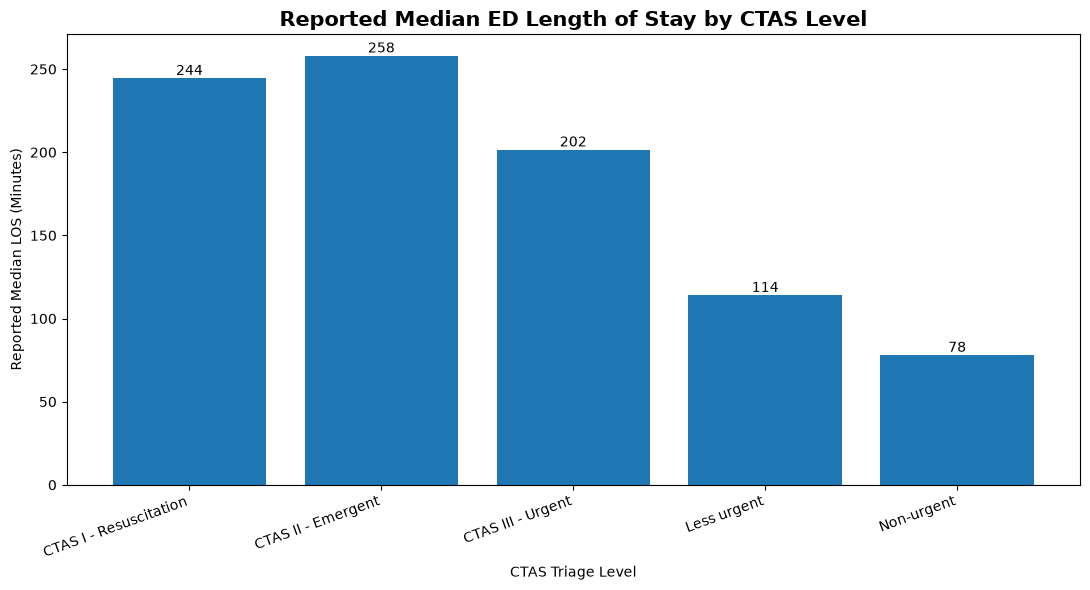

In [29]:
plot_data = (
    h1
    .groupby(
        "triage_level",
        observed=False
    )["median_los_minutes"]
    .median()
    .reindex(
        CTAS_LEVELS
    )
)

# Create the chart
plt.figure(
    figsize=(11, 6)
)

bars = plt.bar(
    CTAS_LEVELS,
    plot_data.values
)

# Chart title
plt.title(
    "Reported Median ED Length of Stay by CTAS Level",
    fontsize=15,
    fontweight="bold"
)

# Axis labels
plt.xlabel(
    "CTAS Triage Level"
)

plt.ylabel(
    "Reported Median LOS (Minutes)"
)

# Rotate long CTAS labels
plt.xticks(
    rotation=20,
    ha="right"
)

# Add the exact median value above each bar
for bar, value in zip(
    bars,
    plot_data.values
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height(),

        f"{value:.0f}",

        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.show()

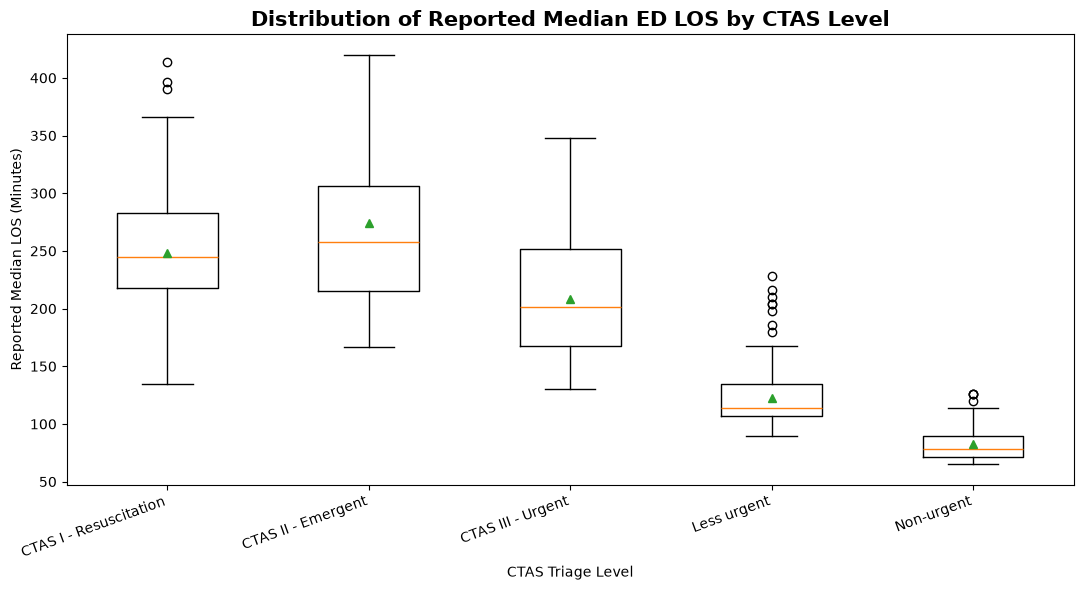

In [30]:
box_data = [
    h1_groups[level]
    for level in CTAS_LEVELS
]

plt.figure(
    figsize=(11, 6)
)

plt.boxplot(
    box_data,
    tick_labels=CTAS_LEVELS,   # Changed from labels=
    showmeans=True
)

plt.title(
    "Distribution of Reported Median ED LOS by CTAS Level",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "CTAS Triage Level"
)

plt.ylabel(
    "Reported Median LOS (Minutes)"
)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()

plt.show()

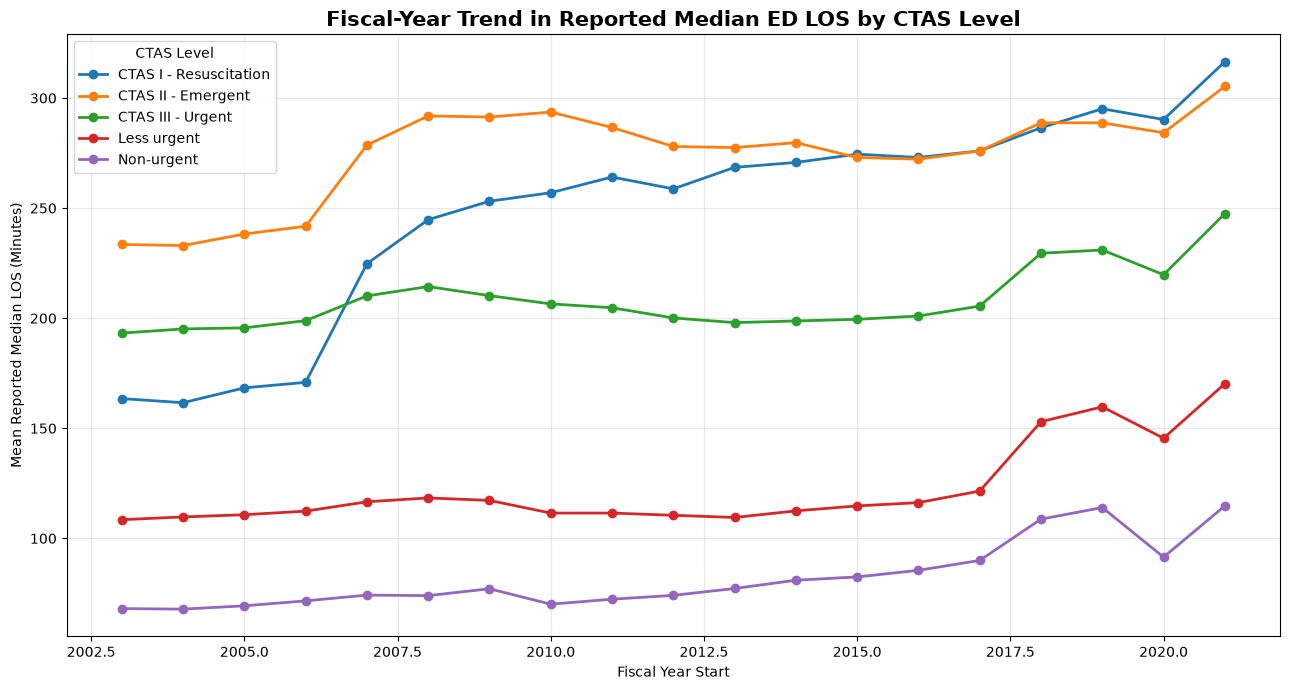

In [25]:
fiscal_candidates = [
    column
    for column in ctas_df.columns
    if (
        "fiscal" in str(column).lower()
        and "year" in str(column).lower()
    )
]


if fiscal_candidates:

    fiscal_col = fiscal_candidates[0]


    trend = pd.DataFrame({

        "fiscal_year":
            ctas_df[fiscal_col],

        "triage_level":
            ctas_df[triage_col]
            .apply(
                standardize_ctas
            ),

        "median_los_minutes":
            pd.to_numeric(
                ctas_df[los_col],
                errors="coerce"
            )
    })


    trend = trend[
        trend["triage_level"].isin(
            CTAS_LEVELS
        )
    ].copy()


    trend["fiscal_year_start"] = pd.to_numeric(
        trend["fiscal_year"]
        .astype(str)
        .str.extract(
            r"(\d{4})"
        )[0],
        errors="coerce"
    )


    trend = trend.dropna(
        subset=[
            "fiscal_year_start",
            "median_los_minutes"
        ]
    )


    year_ctas = (
        trend
        .groupby(
            [
                "fiscal_year_start",
                "triage_level"
            ]
        )[
            "median_los_minutes"
        ]
        .mean()
        .reset_index()
    )


    plt.figure(
        figsize=(13, 7)
    )


    for level in CTAS_LEVELS:

        subset = year_ctas[
            year_ctas[
                "triage_level"
            ] == level
        ]


        if subset.empty:

            continue


        plt.plot(
            subset[
                "fiscal_year_start"
            ],

            subset[
                "median_los_minutes"
            ],

            marker="o",

            linewidth=2,

            label=level
        )


    plt.title(
        "Fiscal-Year Trend in Reported Median ED LOS by CTAS Level",
        fontsize=15,
        fontweight="bold"
    )


    plt.xlabel(
        "Fiscal Year Start"
    )


    plt.ylabel(
        "Mean Reported Median LOS (Minutes)"
    )


    plt.legend(
        title="CTAS Level"
    )


    plt.grid(
        alpha=0.3
    )


    plt.tight_layout()

    plt.show()


else:

    print(
        "Fiscal-year column not found. "
        "Fiscal-year visualization was skipped."
    )

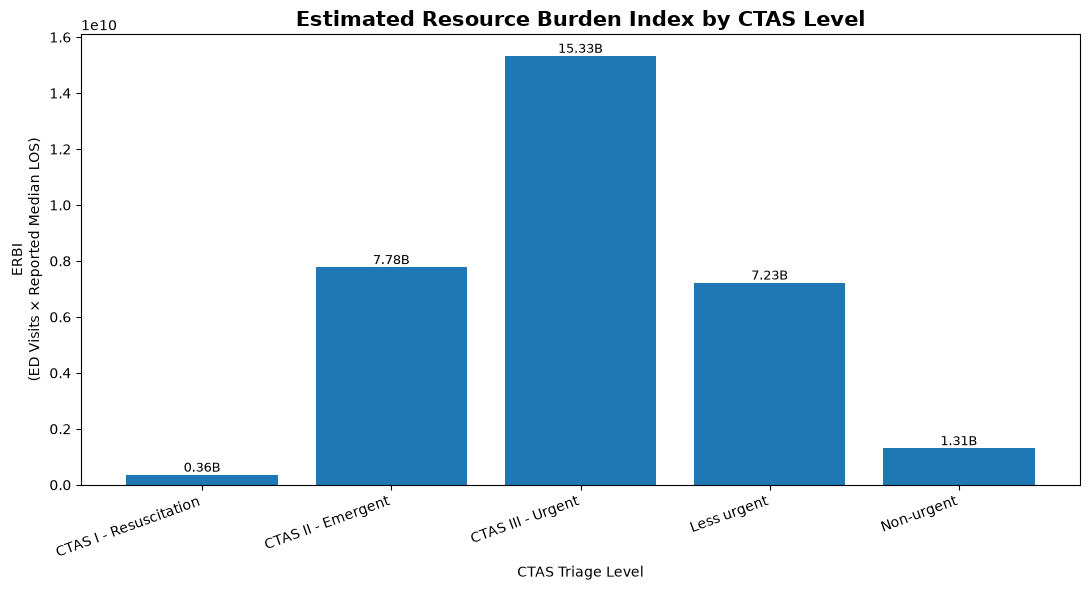

In [26]:
if visits_col is not None:

    erbi = (
        h1
        .assign(
            ERBI=
                h1["ed_visits"]
                *
                h1["median_los_minutes"]
        )
        .groupby(
            "triage_level",
            observed=False
        )["ERBI"]
        .sum()
        .reindex(
            CTAS_LEVELS
        )
    )


    plt.figure(
        figsize=(11, 6)
    )


    bars = plt.bar(
        CTAS_LEVELS,
        erbi.values
    )


    plt.title(
        "Estimated Resource Burden Index by CTAS Level",
        fontsize=15,
        fontweight="bold"
    )


    plt.xlabel(
        "CTAS Triage Level"
    )


    plt.ylabel(
        "ERBI\n"
        "(ED Visits × Reported Median LOS)"
    )


    plt.xticks(
        rotation=20,
        ha="right"
    )


    for bar, value in zip(
        bars,
        erbi.values
    ):

        plt.text(
            bar.get_x()
            + bar.get_width() / 2,

            bar.get_height(),

            f"{value / 1e9:.2f}B",

            ha="center",

            va="bottom",

            fontsize=9
        )


    plt.tight_layout()

    plt.show()


else:

    print(
        "ED visit volume is unavailable. "
        "ERBI cannot be calculated."
    )

In [31]:
N = len(h1)

k = len(CTAS_LEVELS)

epsilon_squared = (
    H_statistic - k + 1
) / (
    N - k
)

print("=" * 80)
print("H1 EFFECT SIZE")
print("=" * 80)

print(
    f"H statistic       : {H_statistic:.6f}"
)

print(
    f"Number of groups  : {k}"
)

print(
    f"Total observations: {N}"
)

print(
    f"Epsilon squared   : {epsilon_squared:.6f}"
)

H1 EFFECT SIZE
H statistic       : 577.528341
Number of groups  : 5
Total observations: 760
Epsilon squared   : 0.759640


In [32]:
# Total number of aggregate observations
N = len(h1)

# Number of CTAS groups
k = len(CTAS_LEVELS)

# Make sure the Kruskal-Wallis statistic exists
if "H_statistic" not in globals():

    raise NameError(
        "H_statistic is not defined. "
        "Run the Kruskal-Wallis test cell first."
    )


# Calculate epsilon squared
epsilon_squared = (
    H_statistic - k + 1
) / (
    N - k
)


# Display the result
print("=" * 80)
print("H1 EFFECT SIZE")
print("=" * 80)

print(
    f"Total observations (N) : {N:,}"
)

print(
    f"Number of CTAS groups (k): {k}"
)

print(
    f"Kruskal-Wallis H       : {H_statistic:.6f}"
)

print(
    f"Epsilon squared (ε²)   : {epsilon_squared:.6f}"
)

H1 EFFECT SIZE
Total observations (N) : 760
Number of CTAS groups (k): 5
Kruskal-Wallis H       : 577.528341
Epsilon squared (ε²)   : 0.759640


In [33]:
# Safety check
required_variables = [
    "H_statistic",
    "p_value",
    "degrees_of_freedom",
    "ALPHA",
    "epsilon_squared",
    "decision"
]

missing_variables = [
    variable
    for variable in required_variables
    if variable not in globals()
]

if missing_variables:

    raise NameError(
        "The following required variables are missing: "
        + ", ".join(missing_variables)
    )


h1_results = pd.DataFrame({

    "Hypothesis": [
        "H1"
    ],

    "Research Question": [
        "Does reported median ED LOS differ across CTAS triage levels?"
    ],

    "Statistical Test": [
        "Kruskal-Wallis"
    ],

    "H Statistic": [
        H_statistic
    ],

    "Degrees of Freedom": [
        degrees_of_freedom
    ],

    "P-value": [
        p_value
    ],

    "Alpha": [
        ALPHA
    ],

    "Epsilon Squared": [
        epsilon_squared
    ],

    "Decision": [
        decision
    ]
})


display(
    h1_results.round(6)
)

,Hypothesis,Research Question,Statistical Test,H Statistic,Degrees of Freedom,P-value,Alpha,Epsilon Squared,Decision
0,H1,Does reported median ED LOS differ across CTAS...,Kruskal-Wallis,577.528,4,0.000,0.050,0.760,Reject H₀


In [34]:
# Number of aggregate observations
N = len(h1)

# Number of CTAS categories
k = len(CTAS_LEVELS)

# Significance level
ALPHA = 0.05


# ------------------------------------------------------------
# EFFECT SIZE
# ------------------------------------------------------------

epsilon_squared = (
    H_statistic - k + 1
) / (
    N - k
)


# ------------------------------------------------------------
# HYPOTHESIS DECISION
# ------------------------------------------------------------

if p_value < ALPHA:

    decision = "Reject H₀"

    conclusion = (
        "There is statistically significant evidence "
        "that reported median ED LOS differs across "
        "CTAS triage levels."
    )

else:

    decision = "Fail to Reject H₀"

    conclusion = (
        "There is insufficient statistical evidence "
        "to conclude that reported median ED LOS differs "
        "across CTAS triage levels."
    )


# ------------------------------------------------------------
# FINAL RESULTS TABLE
# ------------------------------------------------------------

h1_results = pd.DataFrame({

    "Hypothesis": ["H1"],

    "Research Question": [
        "Does reported median ED LOS differ across CTAS triage levels?"
    ],

    "Statistical Test": [
        "Kruskal-Wallis"
    ],

    "H Statistic": [
        H_statistic
    ],

    "Degrees of Freedom": [
        degrees_of_freedom
    ],

    "P-value": [
        p_value
    ],

    "Alpha": [
        ALPHA
    ],

    "Epsilon Squared": [
        epsilon_squared
    ],

    "Decision": [
        decision
    ]
})


# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------

print("=" * 90)
print("H1 — FINAL HYPOTHESIS TEST RESULTS")
print("=" * 90)

display(
    h1_results.round(6)
)


# ------------------------------------------------------------
# HUMAN-READABLE CONCLUSION
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("H1 CONCLUSION")
print("=" * 90)

print(
    f"\nH(4) = {H_statistic:.4f}"
)

print(
    f"p = {p_value:.10g}"
)

print(
    f"ε² = {epsilon_squared:.4f}"
)

print(
    f"\nDecision: {decision}"
)

print(
    f"\n{conclusion}"
)

print(
    "\nInterpretation:"
)

print(
    "The result represents an aggregate-level association "
    "between CTAS triage category and reported median ED LOS. "
    "It should not be interpreted as an individual-patient "
    "effect or a causal relationship."
)

H1 — FINAL HYPOTHESIS TEST RESULTS


,Hypothesis,Research Question,Statistical Test,H Statistic,Degrees of Freedom,P-value,Alpha,Epsilon Squared,Decision
0,H1,Does reported median ED LOS differ across CTAS...,Kruskal-Wallis,577.528,4,0.000,0.050,0.760,Reject H₀



H1 CONCLUSION

H(4) = 577.5283
p = 1.130729867e-123
ε² = 0.7596

Decision: Reject H₀

There is statistically significant evidence that reported median ED LOS differs across CTAS triage levels.

Interpretation:
The result represents an aggregate-level association between CTAS triage category and reported median ED LOS. It should not be interpreted as an individual-patient effect or a causal relationship.
